# Implementing the Backpropagation Algorithm

A Multilayer Perceptron (MLP) Neural Network trained using the Backpropagation Algorithm on a challenging 8-class dataset. This notebook explores the full pipeline — from data preprocessing and class balancing, through architecture design and mathematical formulation, to iterative hyperparameter tuning and model evaluation.

## Initializing the Libraries

The following libraries are required:

| Library | Purpose |
|---------|--------|
| `numpy` | Numerical operations, matrix math, vectorized computations |
| `matplotlib` | Plotting learning curves and dataset distributions |
| `imblearn` | SMOTE for handling class imbalance (depends on `scipy`) |
| `os`, `csv` | File I/O for loading datasets and exporting results |
| `time` | Tracking training duration |

In [1]:
%pip install numpy matplotlib 
%pip install imblearn imbalanced-learn

#imbalanced learn (dependent on scipy) is neaded for SMOTE.

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\C5396183\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\C5396183\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!python --version
!pip list | grep -E "imblearn"

Python 3.13.12


# The Dataset

## Loading the Dataset

The dataset is loaded from CSV files in the `dataset/` directory. Features are dense numerical vectors with 2052 dimensions, and labels range from 1 to 8 (8 classes). Labels are one-hot encoded into an `(N, 8)` matrix for the output layer — each row has a `1.0` at the index corresponding to its class.

A separate unlabeled test set is also loaded for final predictions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os, csv

# loading the data
DATASET     = np.loadtxt(os.path.join("dataset", "data.csv"), delimiter=",")
DATALABELS  = np.loadtxt(os.path.join("dataset", "data_labels.csv"), delimiter=",", dtype=int)
TESTSET     = np.loadtxt(os.path.join("dataset", "test_set.csv"), delimiter=",")

print(f"DATASET : {DATASET.shape}")
print(f"DATALABELS : {DATALABELS.shape}  classes: {np.unique(DATALABELS)}")
print(f"TESTSET : {TESTSET.shape}")

CLASSES = int(np.max(DATALABELS)) #1,2,3,4,5,6,7,8
LABELS = np.zeros((len(DATALABELS), CLASSES), dtype=float) #what class is the data
for _i, label in enumerate(DATALABELS):
    LABELS[_i, int(label) - 1] = 1.0

print(f"LABELS   : {LABELS.shape}")
print(f"Sample   : label {DATALABELS[0]} → {LABELS[0]}")


DATASET : (3486, 354)
DATALABELS : (3486,)  classes: [1 2 3 4 5 6 7 8]
TESTSET : (701, 354)
LABELS   : (3486, 8)
Sample   : label 8 → [0. 0. 0. 0. 0. 0. 0. 1.]


## Dataset Distribution

To observe how balanced or unbalanced the dataset is, a pie chart is generated showing the class distribution.

This is critical — imbalanced data can cause the network to become biased toward the majority class, predicting it disproportionately and ignoring minority classes entirely.

In [4]:

def piechart(datalabels, title='Class Distribution'): #use trainingset labels
    classcounts = np.bincount(datalabels, minlength=9)[1:]
    labels = [f"Class {i}" for i in range(1, len(classcounts) + 1)]

    plt.figure(figsize=(10, 8))
    plt.pie(classcounts, autopct=lambda pct: f'{int(pct/100.*sum(classcounts))}\n({pct:.1f}%)', startangle=90)
    plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title(title)
    plt.axis('equal')
    plt.show()

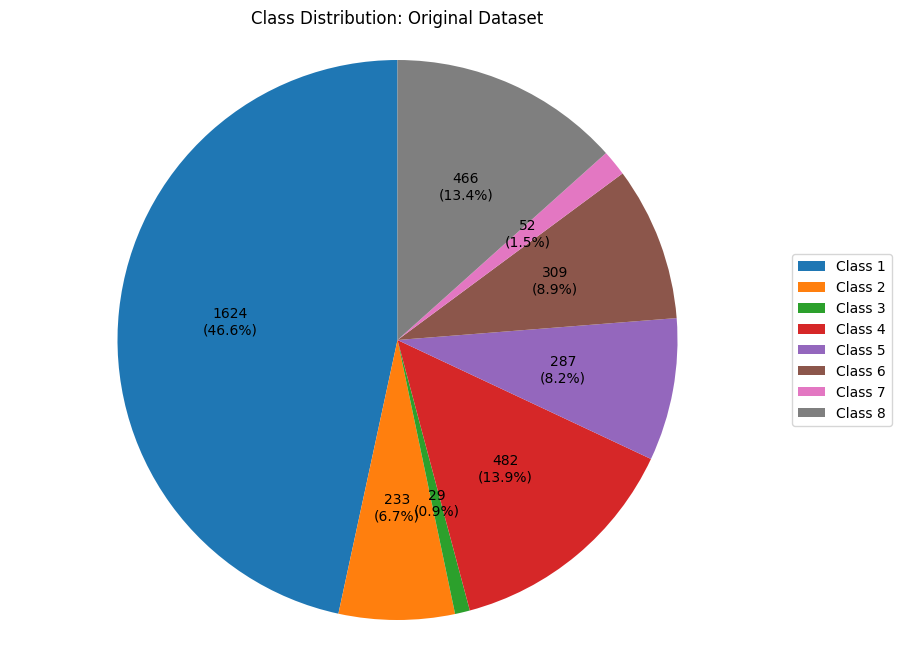

In [5]:
piechart(DATALABELS, "Class Distribution: Original Dataset") #the original

The distribution reveals a significant imbalance. **Class 1 dominates with 46.6%** of the dataset, while **Class 4 holds the smallest share**. This level of skew makes it clear that class balancing is necessary before training — otherwise the network is likely to learn a trivial solution of always predicting the majority class.

## SMOTE (Synthetic Minority Over-sampling Technique)

To address the class imbalance, **SMOTE** is applied to the dataset. SMOTE generates synthetic samples for minority classes by interpolating between existing samples, effectively balancing the class distribution without simply duplicating data points.

In [6]:
X = DATASET
y = DATALABELS

from imblearn.over_sampling import SMOTE

X_balanced, y_balanced = SMOTE(random_state=50).fit_resample(X, y)

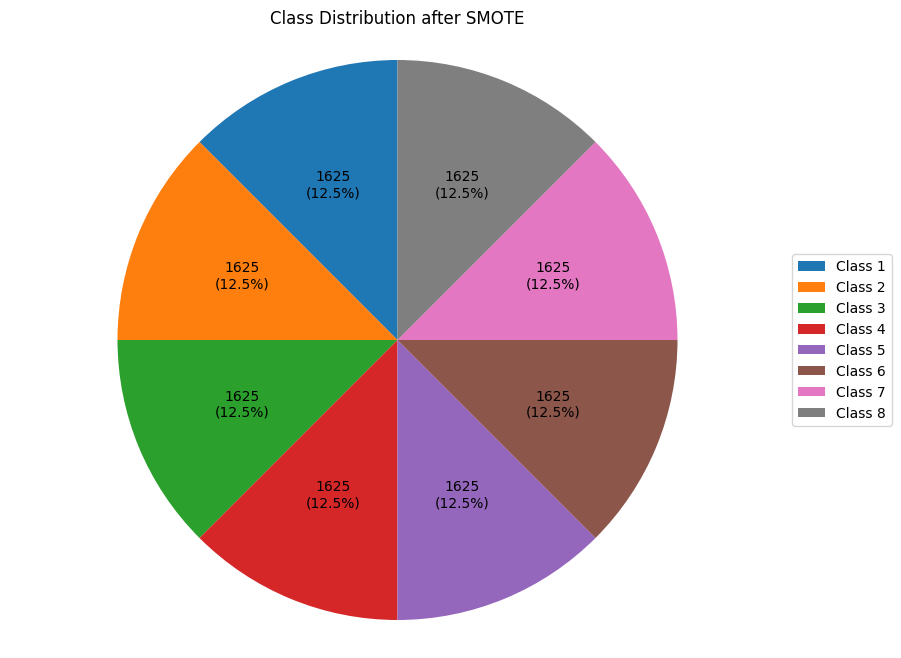

In [7]:
piechart(y_balanced, "Class Distribution after SMOTE")

The dataset is now balanced and ready for training — each class has an equal number of samples, as confirmed by the pie chart.

> **Note on data leakage:** In this implementation, SMOTE was applied *before* splitting into training and validation sets. This means synthetic samples could influence the validation set, potentially leading to optimistic evaluation metrics. Ideally, SMOTE should only be applied to the training fold after the split. This trade-off was accepted for simplicity but is worth noting.

## Partitioning the Dataset

Now that the dataset is balanced and randomized, it is partitioned into training and validation sets using a custom `Partition` class.

- **Validation set:** 800 samples (randomly selected, `random_state=50`)
- **Training set:** remaining samples

The partitions are exported to CSV files (`training_set.csv`, `training_labels.csv`, `validation_set.csv`, `validation_labels.csv`) for reproducibility.

In [8]:
valsize = 800 # fixed validation set size

class Partition: #X is the dataset, y is the datalabels
    def __init__(self, X, y, valsize=800, outputdir="export", randomstate=50):
        os.makedirs(outputdir, exist_ok=True)
        rng = np.random.default_rng(randomstate)

        indices = rng.permutation(len(X))
        validx, trainidx = indices[:valsize], indices[valsize:]

        Xtrain, ytrain = X[trainidx], y[trainidx]
        Xval, yval = X[validx], y[validx]

        self.classes = np.unique(y)
        self.outputdir = outputdir
        self.validationset = Xval
        self.validationlabels = yval
        self.trainingset = Xtrain
        self.traininglabels = ytrain

        self.exportcsv(self.trainingset, "training_set.csv")
        self.exportcsv(self.traininglabels, "training_labels.csv")
        self.exportcsv(self.validationset, "validation_set.csv")
        self.exportcsv(self.validationlabels, "validation_labels.csv")

    def printdetails(self):
        print("Training Set Details")
        print(f"  Shape       : {self.trainingset.shape}")
        print(f"  Label shape : {self.traininglabels.shape}")
        print(f"  Feature min : {self.trainingset.min():.6f}")
        print(f"  Feature max : {self.trainingset.max():.6f}")
        print(f"  Feature mean: {self.trainingset.mean():.6f}")
        # print("\n  Class distribution:")
        # total = len(self.traininglabels)
        # for cls in self.classes:
        #     n = np.sum(self.traininglabels == cls)
        #     print(f"    Class {cls}: {n:>5}  ({n/total*100:.2f}%)")
        piechart(self.traininglabels, "Class Distribution of Training Set")
        print(f"\nValidation Set Details")
        print(f"  Shape       : {self.validationset.shape}")
        print(f"  Label shape : {self.validationlabels.shape}")
        piechart(self.validationlabels, "Class Distribution of Validation Set")

    #all export functions after split
    def exportcsv(self, data, filename):
        path = os.path.join(self.outputdir, filename)
        fmt = "%d" if data.ndim == 1 else "%g"
        np.savetxt(path, data, delimiter=",", fmt=fmt)
        print(f"Saved → {path}  shape: {data.shape}")

Saved → export\training_set.csv  shape: (12200, 354)
Saved → export\training_labels.csv  shape: (12200,)
Saved → export\validation_set.csv  shape: (800, 354)
Saved → export\validation_labels.csv  shape: (800,)
Training Set Details
  Shape       : (12200, 354)
  Label shape : (12200,)
  Feature min : 0.000000
  Feature max : 0.999990
  Feature mean: 0.040234


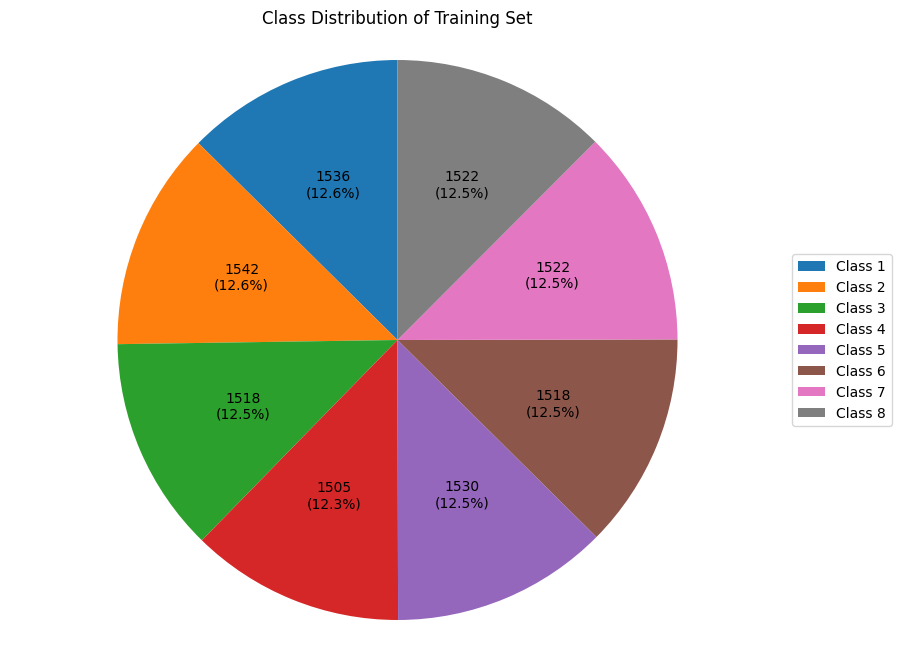


Validation Set Details
  Shape       : (800, 354)
  Label shape : (800,)


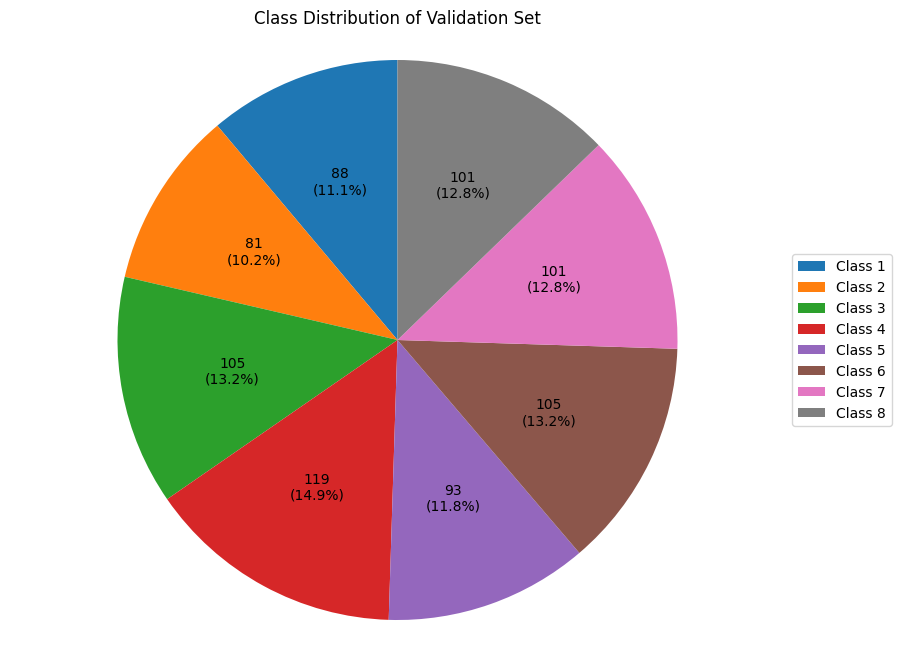

In [9]:
split = Partition(X_balanced, y_balanced)
split.printdetails()

## Batch Size

Mini-batch gradient descent is used with a **batch size of 8**. A generator function `minibatch()` yields sequential slices of the training set and labels for each batch iteration. This allows vectorized computation within each batch while still updating weights multiple times per epoch.

In [10]:
def minibatch(trainingset, traininglabels, batch_size=8):
    N = len(trainingset)
    indices = np.arange(N)
    for start in range(0, N, batch_size):
        i = indices[start : start + batch_size]
        yield trainingset[i], traininglabels[i]

In [11]:
batch_size = 8 #edit this to get the batch size you need
minibatch(split.trainingset, split.traininglabels, batch_size)

<generator object minibatch at 0x0000021D0946A040>

# Setting up the Equations

The backpropagation algorithm is defined by a sequence of mathematical equations that govern forward propagation, error computation, delta calculation, and weight updating. The following sections lay out each equation as implemented in the code.

## Full Equation Reference: Backpropagation Algorithm

> **Notation**
> | Symbol | Meaning |
> |--------|---------|
> | $L$ | Total number of layers (output layer index) |
> | $l$ | Current layer index, $l \in \{1, \dots, L\}$ |
> | $i$ | Index of neuron in layer $l-1$; $i = 0$ is the bias input |
> | $j$ | Index of neuron in layer $l$ |
> | $k$ | Index of neuron in output layer $L$ |
> | $w^{(l)}_{j0}$ | Bias weight of neuron $j$ in layer $l$ (fixed input $\varphi_0 = +1$) |
> | $w^{(l)}_{ji}$ | Weight from neuron $i$ in layer $l-1$ to neuron $j$ in layer $l$ |
> | $v^{(l)}_j$ | Internal activity (pre-activation) of neuron $j$ in layer $l$ |
> | $\varphi_j$ | Activation function of neuron $j$; output $\varphi_j\!\left(v^{(l)}_j\right)$ |
> | $d_k$ | Desired (target) output for output neuron $k$ |
> | $e_k(n)$ | Error at output neuron $k$ at epoch $n$ |
> | $\mathcal{E}(n)$ | Mean square error over all output neurons at epoch $n$ |
> | $\eta$ | Learning rate |
> | $\alpha$ | Momentum coefficient |
> | $a, b$ | Depends on activation function. Used by Logistic and Tanh as constant/s, Leaky ReLU negative-side slope, $\gamma \in (0,1)$ |
> | $n$ | Discrete time step (epoch) |
 
---

## 1. Forward Propagation to get internal activity $v(n)$ and outputs $y_{out}$

### 1.1 Internal Activity
 
The sum begins at $i = 0$ to include the bias weight $w^{(l)}_{j0}$ directly. The bias neuron has a fixed output of $+1$, so $w^{(l)}_{j0} \cdot 1 = w^{(l)}_{j0}$:
 
$$v^{(l)}_j(n) = \sum_{i=0}^{p} w^{(l)}_{ji}(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
where $p$ is the number of neurons in layer $l-1$ (excluding the bias), and the bias input is $\varphi_0 = +1$ (constant).
 
### 1.2 Neuron Output
 
$$y_j(n) = \varphi_j\!\left(v^{(l)}_j(n)\right)$$
 
where $\varphi_j$ is the chosen activation function (see Section 2).

## 2. Choosing the Activation Functions
 
Derivatives are expressed in terms of the neuron output $o(n) = \varphi(v(n))$ directly, using constants $a$ and $b$ where applicable.
 
### 2.1 Logistic (Sigmoid)
 
$$\varphi(v) = \frac{1}{1 + e^{-av}}, \quad a > 0$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = a \cdot o(n)\,\bigl(1 - o(n)\bigr)$$

> Given: $a = 2.0$
 
---
 
### 2.2 Hyperbolic Tangent (Tanh)
 
$$\varphi(v) = a \tanh(bv) = a \cdot \frac{e^{bv} - e^{-bv}}{e^{bv} + e^{-bv}}$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \frac{b}{a}\left(a - o(n)\right)\!\left(a + o(n)\right)$$
 
> Given: $a = 1.716,\; b = 0.66667$
 
---
 
### 2.3 Leaky ReLU
 
$$\varphi(v) = \begin{cases} v & \text{if } v > 0 \\ \gamma\, v & \text{if } v \leq 0 \end{cases}, \quad \gamma \in (0,1)$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \begin{cases} 1 & \text{if } o(n) > 0 \\ \gamma & \text{if } o(n) \leq 0 \end{cases}$$
 
---

In [12]:
# ACTIVATION FUNCTIONS
def logistic(v, a=1.0):
    phi = 1.0 / (1.0 + np.exp(-a * v))
    return phi

def tanh(v, a=1.0, b=1.0):
    phi = a * np.tanh(b * v)
    return phi
 
def leakyrelu(v, gamma=0.01):
    phi = np.where(v > 0, v, gamma * v)
    return phi
 
def errorSignal(dk, phiVk):
    return dk - phiVk
 
def meanSquareError(ek):
    return 0.5 * np.dot(ek, ek)

# DERIVATIVES
RELU_CLIP = 5.0 #for relu to converge

def dlogistic(o, a=1.0):
    dphi = a * o * (1.0 - o)
    return dphi
 
def dtanh(o, a=1.0, b=1.0):
    dphi = (b / a) * (a - o) * (a + o)
    return dphi
 
def dleakyrelu(o, gamma=0.01):
    dphi = np.where(o > 0, 1.0, gamma)
    return dphi
 
# DERIVATIVE CALL
def callDerivative(method, o, config):
    if method == 0:
        return dlogistic(o, config['a_l']), None
    elif method == 1:
        return dtanh(o, config['a_tanh'], config['b_tanh']), None
    else:
        return dleakyrelu(o, config['a_relu']), RELU_CLIP
 
# ACTIVATION CALL
def callActivation(method, v, config):
    if method == 0:
        return logistic(v, config['a_l'])
    elif method == 1:
        return tanh(v, config['a_tanh'], config['b_tanh'])
    else:
        return leakyrelu(v, config['a_relu'])

## 3. Error & Mean Square Error
 
### 3.1 Error Signal at Output Neuron $k$
 
$$o_k(n)= s \varphi_k\!\left(v^{(L)}_k(n)\right)$$
 
### 3.2 Mean Square Error
 
$$\mathcal{E}(n) = \frac{1}{2} \sum_{k \in \mathcal{C}} e_k^2(n)$$
 
where $\mathcal{C}$ is the set of output neurons.
 
---

## 4. Backpropagation Delta Equations
 
### 4.1 Output Layer Delta
 
$$\delta^{(L)}_k(n) = e_k(n) \cdot \varphi'\!\left(v^{(L)}_k(n)\right)$$
 
### 4.2 Hidden Layer Delta
 
For layer $l \in \{L-1,\, L-2,\, \dots,\, 1\}$:
 
$$\delta^{(l)}_j(n) = \varphi'\!\left(v^{(l)}_j(n)\right) \cdot \sum_{k}\, \delta^{(l+1)}_k(n)\, w^{(l+1)}_{kj}(n)$$
 
The hidden-layer delta propagates the error signal backward by weighting each upstream delta $\delta^{(l+1)}_k$ by the corresponding weight $w^{(l+1)}_{kj}$ and scaling by the local derivative $\varphi'(v^{(l)}_j)$.
 
---

## 5. Weight Update: Negative Gradient with Momentum
 
All weights $w^{(l)}_{ji}$ include the bias weights at $i = 0$ (with fixed input $\varphi_0 = +1$). No separate bias update is needed.
 
The weight correction follows the **negative gradient** of $\mathcal{E}(n)$ with respect to $w^{(l)}_{ji}$:
 
$$-\frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)} = \delta^{(l)}_j(n) \cdot \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.1 Weight Increment (Generalized Delta Rule + Momentum)
 
$$\Delta w^{(l)}_{ji}(n) = \underbrace{\alpha\, \Delta w^{(l)}_{ji}(n-1)}_{\text{momentum}} \;-\; \underbrace{\eta\, \frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)}}_{\text{negative gradient}}$$
 
Substituting the gradient expression:
 
$$\Delta w^{(l)}_{ji}(n) = \alpha\, \Delta w^{(l)}_{ji}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.2 Weight Update Rule
 
$$w^{(l)}_{ji}(n+1) = w^{(l)}_{ji}(n) + \Delta w^{(l)}_{ji}(n)$$
 
> **Bias weights** ($i = 0$) are updated identically using $\varphi_0 = +1$, so:
> $$\Delta w^{(l)}_{j0}(n) = \alpha\, \Delta w^{(l)}_{j0}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)$$
 
> **Momentum note:** When $\alpha = 0$, this reduces to the standard (vanilla) delta rule. When $\alpha > 0$, the update accumulates a fraction of the previous step, smoothing oscillations and accelerating convergence along consistent gradient directions.
 
---

In [13]:
class OutputLayer:
    def __init__(self, method, w_old, config, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.o = []
        self.d = []
        self.w_old = w_old
        self.size = config['size']
        self.delta = []
        self.error = []
        self.mse = 0.0
        self.w_new = []
        self.totaltime = 0
 
        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.o = callActivation(self.method, self.v, self.config)
 
    def computeError(self, d):
        self.d = np.asarray(d, dtype=float)
        self.error = errorSignal(self.d, self.o)
        self.mse = meanSquareError(self.error)
 
    def computeDelta(self):
        dphi, _ = callDerivative(self.method, self.o, self.config)
        self.delta = self.error * dphi
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
 
 
class HiddenLayer:
    def __init__(self, method, w_old, config, size=8, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.y = []
        self.w_old = w_old
        self.size = size
        self.delta = 0.0
        self.w_new = []

        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.y = callActivation(self.method, self.v, self.config)
        return np.concatenate(([1.0], self.y))
 
    def computeDelta(self, nextLayer):
        dphi, _ = callDerivative(self.method, self.y, self.config)
        w_nobias = nextLayer.w_old[:, 1:]
        propagated = w_nobias.T @ nextLayer.delta
        self.delta = dphi * propagated
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        _, clip = callDerivative(self.method, self.y, self.config)
        if clip is not None:
            norm = np.linalg.norm(dw)
            if norm > clip:
                dw = dw * (clip / norm)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
        return self.w_new
 
 
class Epoch:
    def __init__(self, split, config):
        self.config = config

        inputsize  = split.trainingset.shape[1] + 1
        hiddensize = config['size']
        outputsize = len(split.classes)
        #randomizing start weights
        Wi = np.random.randn(hiddensize, inputsize) * 0.01
        Wj = np.random.randn(hiddensize, hiddensize + 1)  * 0.01
        Wk = np.random.randn(outputsize, hiddensize + 1)  * 0.01

        self.hiddenlayer_i = HiddenLayer(config['methods'][0], Wi, config, size=hiddensize)
        self.hiddenlayer_j = HiddenLayer(config['methods'][1], Wj, config, size=hiddensize)
        self.outputlayer_k = OutputLayer(config['methods'][2], Wk, config)

        self.test_set = list(zip(split.validationset, split.validationlabels))
        self.error = 0.0 #for scores
        
        self.batch_iteration = 0
        self.epoch_iteration = 0

        #for export
        self.train_errors = []
        self.val_errors = []
        self.epochs_logged = []
        
        self.tp = self.tn = self.fp = self.fn = 0.0
        self.p = self.r = self.a = self.f1 = self.matthews = 0.0

        self.trainingset = split.trainingset
        self.traininglabels = split.traininglabels
 
    def run(self, x, d):
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
 
        # Forward Prop
        phi_i = self.hiddenlayer_i.forward(x_biased)
        phi_j = self.hiddenlayer_j.forward(phi_i)
        self.outputlayer_k.forward(phi_j)
 
        outputsize = self.outputlayer_k.w_old.shape[0]
        d_onehot = np.zeros(outputsize)
        d_onehot[int(d) - 1] = 1.0

        # Error calcs
        self.outputlayer_k.computeError(d_onehot)
        self.error = self.outputlayer_k.mse
 
        # Backprop
        self.outputlayer_k.computeDelta()
        self.hiddenlayer_j.computeDelta(self.outputlayer_k)
        self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
        # Accumulate (batch_size=1, so gradient = outer(delta, phiIn))
        self.outputlayer_k.accumulateGradient()
        self.hiddenlayer_j.accumulateGradient()
        self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates
        self.outputlayer_k.updateWeights()
        self.hiddenlayer_j.updateWeights()
        self.hiddenlayer_i.updateWeights()
 
        # Advance w_old → w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.epoch_iteration += 1
 
    def run_batch(self, X_batch, D_batch):
        batch_size = len(X_batch)
        error = 0.0
 
        for SAMPLE in range(batch_size):
            x_biased = np.concatenate(([1.0], np.asarray(X_batch[SAMPLE], dtype=float)))
 
            # Forward Prop
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            outputsize = self.outputlayer_k.w_old.shape[0]
            d_onehot = np.zeros(outputsize)
            d_onehot[int(D_batch[SAMPLE]) - 1] = 1.0

            # Error calcs
            self.outputlayer_k.computeError(d_onehot)
            error += self.outputlayer_k.mse
 
            # Backprop
            self.outputlayer_k.computeDelta()
            self.hiddenlayer_j.computeDelta(self.outputlayer_k)
            self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
            # Accumulate
            self.outputlayer_k.accumulateGradient()
            self.hiddenlayer_j.accumulateGradient()
            self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates uses batch_size from config
        self.outputlayer_k.updateWeights(batch_size)
        self.hiddenlayer_j.updateWeights(batch_size)
        self.hiddenlayer_i.updateWeights(batch_size)
 
        # Advance w_old to w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.error = error / batch_size
        self.batch_iteration += 1
        return self.error
 
    def Scores(self):
        n_classes = self.outputlayer_k.w_old.shape[0]
        confmat = np.zeros((n_classes, n_classes), dtype=int)
        for x, d in self.test_set:
            x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            predicted = np.argmax(self.outputlayer_k.o)
            actual = int(d) - 1   # labels are 1-8; convert to 0-indexed
 
            confmat[actual, predicted] += 1
 
        self.confmat = confmat
        total   = confmat.sum()
        correct = np.trace(confmat)
        self.a  = correct / total if total > 0 else 0.0
 
        # --- Per-class TP, TN, FP, FN and Macro-averaged precision, recall, F1, totaltime ---
        tps, tns, fps, fns = [], [], [], []
        precisions, recalls, f1s = [], [], []
        for c in range(n_classes):
            tp = confmat[c, c]
            fp = confmat[:, c].sum() - tp
            fn = confmat[c, :].sum() - tp
            tn = total - tp - fp - fn
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0.0
            tps.append(int(tp))
            tns.append(int(tn))
            fps.append(int(fp))
            fns.append(int(fn))
            precisions.append(prec)
            recalls.append(rec)
            f1s.append(f1)
        self.tps = tps
        self.tns = tns
        self.fps = fps
        self.fns = fns
        self.precisions = precisions
        self.recalls = recalls
        self.f1s = f1s
        self.p  = np.mean(precisions)
        self.r  = np.mean(recalls)
        self.f1 = np.mean(f1s)

        # Matthews Correlation Coefficient (multiclass)
        tk = confmat.sum(axis=0)
        pk = confmat.sum(axis=1)
        c_total = confmat.sum()
        c_correct = np.trace(confmat)
        cov_yy = c_total * c_correct - np.dot(tk, pk)
        cov_xx = c_total**2 - np.dot(tk, tk)
        cov_yy_denom = c_total**2 - np.dot(pk, pk)
        denom = np.sqrt(float(cov_xx) * float(cov_yy_denom))
        self.matthews = float(cov_yy) / denom if denom > 0 else 0.0
 
    def printConfusionMatrix(self):
        n = self.confmat.shape[0]
        print("Confusion Matrix (rows=Actual, cols=Predicted):")
        header = "      " + "  ".join(f"P{i+1:>2}" for i in range(n))
        print(header)
        for i in range(n):
            row = "  ".join(f"{self.confmat[i, j]:>4}" for j in range(n))
            print(f"A{i+1:>2} | {row}")
 
    def printScores(self):
        self.printConfusionMatrix()
        n = self.confmat.shape[0]
        print()
        print("Per-Class Metrics:")
        print(f"  {'Class':<8} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
        print(f"  {'-'*8} {'-'*6} {'-'*6} {'-'*6} {'-'*6} {'-'*10} {'-'*10} {'-'*10}")
        for c in range(n):
            print(f"  {'Class '+str(c+1):<8} {self.tps[c]:>6} {self.tns[c]:>6} {self.fps[c]:>6} {self.fns[c]:>6} {self.precisions[c]:>10.5f} {self.recalls[c]:>10.5f} {self.f1s[c]:>10.5f}")
        print()
        print("Summary Metrics:")
        print(f"  Error (MSE):                  {self.error:.5f}")
        print(f"  Accuracy:                     {self.a:.5f}")
        print(f"  Precision (Macro-Avg):        {self.p:.5f}")
        print(f"  Recall (Macro-Avg):           {self.r:.5f}")
        print(f"  F1 Score (Macro-Avg):         {self.f1:.5f}")
        print(f"  Matthews Correlation Coeff:   {self.matthews:.5f}")
 
    def log_epoch(self, epoch_idx, train_error, val_error):
        self.epochs_logged.append(epoch_idx)
        self.train_errors.append(train_error)
        self.val_errors.append(val_error)

    def exportErrors(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "errors.csv")

        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['epoch', 'train_error', 'val_error'])

            for ep, tr, val in zip(self.epochs_logged, self.train_errors, self.val_errors):
                writer.writerow([ep, tr, val])
 
    def exportScores(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "scores.csv")
        n = self.confmat.shape[0]
        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)

            # Write header
            header = ['Epoch']
            for c in range(n):
                cn = f"class{c+1}"
                header.extend([f"{cn}_TP", f"{cn}_TN", f"{cn}_FP", f"{cn}_FN",
                            f"{cn}_Precision", f"{cn}_Recall", f"{cn}_F1"])
            header.extend(['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'matthews', "Time"])
            writer.writerow(header)

            # Write the row
            row = [self.epoch_iteration]
            for c in range(n):
                row.extend([self.tps[c], self.tns[c], self.fps[c], self.fns[c],
                            self.precisions[c], self.recalls[c], self.f1s[c]])
            row.extend([self.a, self.p, self.r, self.f1, self.matthews, self.totaltime])
            writer.writerow(row)

    def exportConfusionMatrix(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "confusion_matrix.csv")
        n = len(self.tps)  # number of classes

        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)
            # Header
            writer.writerow(['Class', 'TP', 'TN', 'FP', 'FN', 'Precision', 'Recall', 'F1'])
            # Write per-class stats
            for c in range(n):
                writer.writerow([
                    f'Class {c+1}',
                    self.tps[c],
                    self.tns[c],
                    self.fps[c],
                    self.fns[c],
                    f'{self.precisions[c]:.5f}',
                    f'{self.recalls[c]:.5f}',
                    f'{self.f1s[c]:.5f}'
                ])
        print(f"Saved → {filepath}  shape: {n} classes")

    def exportWeights(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        weights = [
            (self.hiddenlayer_i.w_old, "Wi"),
            (self.hiddenlayer_j.w_old, "Wj"),
            (self.outputlayer_k.w_old, "Wk"),
        ]
        path = os.path.join(outputdir, "trained_weights.csv")
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
            for data, label in weights:
                writer.writerow([label])
                if data.ndim == 1:
                    writer.writerow(data.astype(int))
                else:
                    for row in data:
                        writer.writerow(row)
                writer.writerow([])
        print(f"Saved → {path}")

    def exportAll(self, outputdir="export"):
        self.exportErrors(outputdir)
        self.exportScores(outputdir)
        self.exportConfusionMatrix(outputdir)
        self.exportWeights(outputdir)


# Training Phase

With the equations implemented in the `HiddenLayer`, `OutputLayer`, and `Epoch` classes, the training phase can begin. Each training run processes the dataset in mini-batches, computes training and validation errors per epoch, and prints progress every 5 epochs.

## Hyperparameters Setup

Two network configurations are defined below, differing primarily in their activation functions:

| Parameter | Network A (Tanh) | Network B (Leaky ReLU) |
|-----------|-------------------|------------------------|
| Hidden activation | Tanh ($a=1.716, b=2/3$) | Leaky ReLU ($\gamma=0.01$) |
| Output activation | Logistic ($a=1.0$) | Logistic ($a=1.0$) |
| Learning rate ($\eta$) | 0.85 | 0.85 |
| Momentum ($\alpha$) | 0.9 | 0.9 |
| Hidden layer size | 8 | 8 |
| Batch size | 8 | 8 |

The architecture uses **two hidden layers** (layers $i$ and $j$) plus an **output layer** ($k$), with 8 output neurons for 8 classes.

In [14]:
#hyperparameters updated
NetworkA = {
        'methods'    : [1, 1, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,       # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # mini-batch size
    }
NetworkB = {
        'methods'    : [2, 2, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 1.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,        # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # mini-batch size
    }
#the main engine:
epochA = Epoch(split, NetworkA)  # layers built inside
epochB = Epoch(split, NetworkB)

## Training: Network A

The training phase begins with Network A using the default hyperparameters. Runtime and error for each training run are printed every 5 epochs.

With the default configuration (`eta=0.85`, `alpha=0.9`, `size=8`), the error remained essentially flat across all 100 epochs. The resulting F1 score was a dismal **0.0324** — the network was effectively guessing a single class. This indicated that the learning rate was too aggressive and the momentum too high, causing weight updates to overshoot.

In [15]:
import time

def computeValError(epoch):
    total_mse = 0.0
    n = len(epoch.test_set)
    for x, d in epoch.test_set:
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
        phi_i = epoch.hiddenlayer_i.forward(x_biased)
        phi_j = epoch.hiddenlayer_j.forward(phi_i)
        epoch.outputlayer_k.forward(phi_j)
        n_out = epoch.outputlayer_k.w_old.shape[0]
        d_onehot = np.zeros(n_out)
        d_onehot[int(d) - 1] = 1.0
        epoch.outputlayer_k.computeError(d_onehot)
        total_mse += epoch.outputlayer_k.mse
    return total_mse / n if n > 0 else 0.0

def learningcurve(train_errors, val_errors, networkname="Learning Curve: Training vs Validation Error"):
    epochs = range(1, len(train_errors) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_errors, label="Training Error (MSE)")
    plt.plot(epochs, val_errors,   label="Validation Error (MSE)")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(networkname)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def train(epoch, networkname = "Learning Curve: Training vs Validation Error", epochs=100):
    batch_size   = epoch.config.get('batch_size', 8)

    totaltime = 0
    for ep in range(epochs):
        start = time.time()
        epoch_error = 0.0
        n_batches = 0
        for xbatch, dbatch in minibatch(epoch.trainingset, epoch.traininglabels, batch_size):
            epoch_error += epoch.run_batch(xbatch, dbatch)
            n_batches += 1
        epoch_error /= max(n_batches, 1)
        
        epoch.error = epoch_error #updating errors
        epoch.epoch_iteration = ep + 1
        val_error = computeValError(epoch)

        epoch.log_epoch(epoch.epoch_iteration, epoch_error, val_error)

        elapsed = time.time() - start
        totaltime += elapsed
        if (ep + 1) % 5 == 0:
            print(f"Epoch {ep+1:>4}  Train: {epoch_error:.5f}  Val: {val_error:.5f}  Time: {elapsed:.3f}s")
    epoch.totaltime = totaltime
    epoch.Scores()
    epoch.printScores()
    print(f"Total training time: {totaltime:.2f}s")
    learningcurve(epoch.train_errors, epoch.val_errors, networkname)

Epoch    5  Train: 0.49974  Val: 0.50000  Time: 0.545s
Epoch   10  Train: 0.49999  Val: 0.49998  Time: 0.542s
Epoch   15  Train: 0.50000  Val: 0.50000  Time: 0.752s
Epoch   20  Train: 0.50000  Val: 0.50000  Time: 0.655s
Epoch   25  Train: 0.50000  Val: 0.50000  Time: 0.596s
Epoch   30  Train: 0.50000  Val: 0.50000  Time: 0.578s
Epoch   35  Train: 0.50000  Val: 0.50000  Time: 0.577s
Epoch   40  Train: 0.50000  Val: 0.50000  Time: 0.638s
Epoch   45  Train: 0.50000  Val: 0.50000  Time: 0.584s
Epoch   50  Train: 0.50000  Val: 0.50000  Time: 0.606s
Epoch   55  Train: 0.50000  Val: 0.50000  Time: 0.576s
Epoch   60  Train: 0.50000  Val: 0.50000  Time: 0.596s
Epoch   65  Train: 0.50000  Val: 0.50000  Time: 0.632s
Epoch   70  Train: 0.50000  Val: 0.50000  Time: 0.547s
Epoch   75  Train: 0.50000  Val: 0.50000  Time: 0.656s
Epoch   80  Train: 0.50000  Val: 0.50000  Time: 0.586s
Epoch   85  Train: 0.50000  Val: 0.50000  Time: 0.555s
Epoch   90  Train: 0.49983  Val: 0.49998  Time: 0.551s
Epoch   95

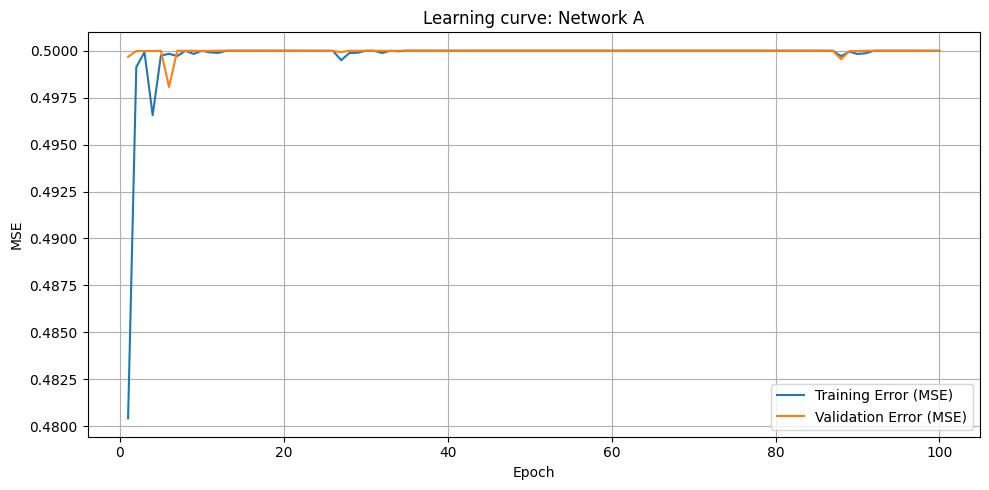

Saved → export/networkA/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA/trained_weights.csv


In [16]:
train(epochA, "Learning curve: Network A") #network A

epochA.exportAll("export/networkA/")

### Improvements for Network A

Improvements are needed since the error does not converge with the default parameters. The learning rate is lowered from 0.85 to **0.1**, momentum reduced from 0.9 to **0.5**, and hidden layer size increased from 8 to **12**.

These adjustments target the core issue: the original learning rate was too aggressive, causing the weight updates to overshoot the optimal region of the loss surface.

Epoch    5  Train: 0.43759  Val: 0.43710  Time: 0.689s
Epoch   10  Train: 0.25655  Val: 0.22210  Time: 0.665s
Epoch   15  Train: 0.10937  Val: 0.11031  Time: 0.638s
Epoch   20  Train: 0.05534  Val: 0.04964  Time: 0.578s
Epoch   25  Train: 0.03871  Val: 0.03436  Time: 0.604s
Epoch   30  Train: 0.03152  Val: 0.02672  Time: 0.636s
Epoch   35  Train: 0.02646  Val: 0.02764  Time: 0.620s
Epoch   40  Train: 0.02410  Val: 0.01916  Time: 0.790s
Epoch   45  Train: 0.02206  Val: 0.02048  Time: 0.717s
Epoch   50  Train: 0.01910  Val: 0.01969  Time: 0.685s
Epoch   55  Train: 0.01880  Val: 0.02578  Time: 0.753s
Epoch   60  Train: 0.01608  Val: 0.04045  Time: 0.683s
Epoch   65  Train: 0.01515  Val: 0.01773  Time: 0.629s
Epoch   70  Train: 0.01480  Val: 0.01491  Time: 0.690s
Epoch   75  Train: 0.01337  Val: 0.01569  Time: 0.615s
Epoch   80  Train: 0.01337  Val: 0.01519  Time: 0.890s
Epoch   85  Train: 0.01242  Val: 0.01837  Time: 0.779s
Epoch   90  Train: 0.01125  Val: 0.01554  Time: 0.687s
Epoch   95

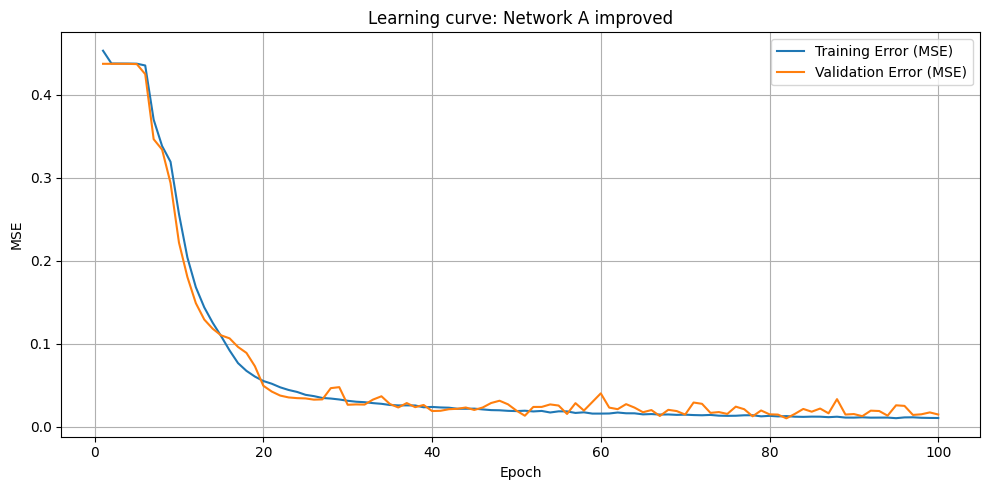

Saved → export/networkA_improv/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv/trained_weights.csv


In [17]:
NetworkA['eta'] = 0.1 #lowering the learning rate
NetworkA['alpha'] = 0.5 #lowering the momentum
NetworkA['size'] = 12 #increasing the number of hidden layers

epochA_improv = Epoch(split, NetworkA)

train(epochA_improv, "Learning curve: Network A improved")
epochA_improv.exportAll("export/networkA_improv/")

The errors are now converging, and the validation error aligns well with the training error. Training time is the same even if we add hidden layers, suggesting a hardware or algorithm bottleneck. Since convergence happened early, training could reasonably be stopped around the **50th epoch**, though we will keep on maintaining 100 Epochs for testing purposes.

### Lowering learning rate further

The next step is to test whether a lower learning rate does help in accuracy or change speed.

Epoch    5  Train: 0.43765  Val: 0.43751  Time: 0.654s
Epoch   10  Train: 0.43650  Val: 0.43502  Time: 0.636s
Epoch   15  Train: 0.33785  Val: 0.34212  Time: 0.647s
Epoch   20  Train: 0.19845  Val: 0.18999  Time: 0.676s
Epoch   25  Train: 0.12668  Val: 0.12204  Time: 0.668s
Epoch   30  Train: 0.07946  Val: 0.08446  Time: 0.683s
Epoch   35  Train: 0.05118  Val: 0.06957  Time: 0.614s
Epoch   40  Train: 0.03875  Val: 0.04553  Time: 0.582s
Epoch   45  Train: 0.03196  Val: 0.04369  Time: 0.630s
Epoch   50  Train: 0.02828  Val: 0.04038  Time: 0.629s
Epoch   55  Train: 0.02410  Val: 0.04015  Time: 0.607s
Epoch   60  Train: 0.02147  Val: 0.03215  Time: 0.643s
Epoch   65  Train: 0.01938  Val: 0.03774  Time: 0.600s
Epoch   70  Train: 0.01781  Val: 0.03377  Time: 0.625s
Epoch   75  Train: 0.01657  Val: 0.03522  Time: 0.698s
Epoch   80  Train: 0.01578  Val: 0.03340  Time: 0.613s
Epoch   85  Train: 0.01473  Val: 0.03069  Time: 0.628s
Epoch   90  Train: 0.01381  Val: 0.02605  Time: 0.632s
Epoch   95

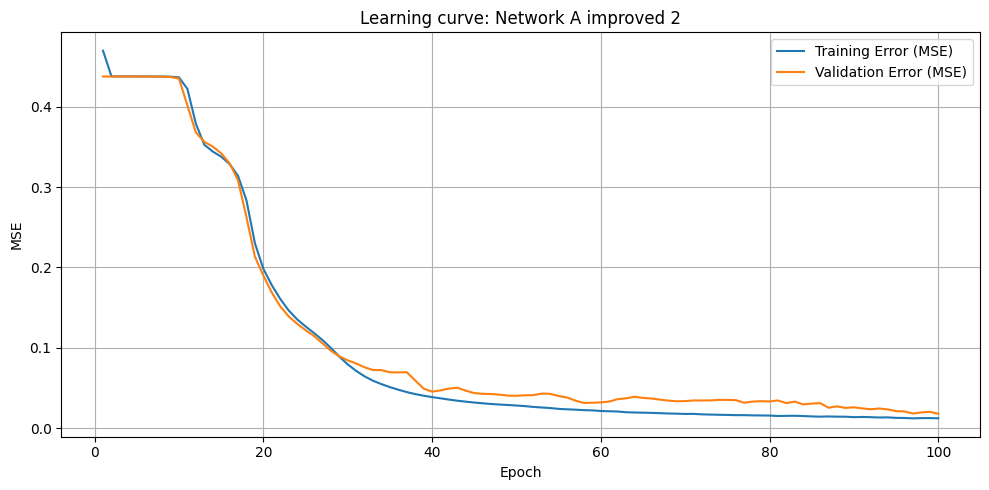

Saved → export/networkA_improv2/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2/trained_weights.csv


In [18]:
NetworkA['eta'] = 0.05 #decreasing learning rate to check if performance increases
NetworkA['alpha'] = 0.5 #keeping momentum
NetworkA['size'] = 12 #keeping same number 


epochA_improv2 = Epoch(split, NetworkA)

train(epochA_improv2, "Learning curve: Network A improved 2")
epochA_improv2.exportAll("export/networkA_improv2/")

This is roughly the same end result as the first one, which shows that we are at the sweet spot of learning rate, so there is no point lowering or increasing it further. It was noted that it needed the whole **100 epochs** so that errors are less than 0.02000, expected as the learning rate essentially halved.

Interestingly, **validation error** is less stable on this run. Time is slightly faster (64s) but still negligible compared to before.

### Increasing momentum

An attempt to increase momentum will be done next. It is expected that early epochs would converge to a lower error faster.

Epoch    5  Train: 0.21857  Val: 0.17417  Time: 0.611s
Epoch   10  Train: 0.06936  Val: 0.14285  Time: 0.585s
Epoch   15  Train: 0.04274  Val: 0.08678  Time: 0.603s
Epoch   20  Train: 0.03443  Val: 0.02005  Time: 0.579s
Epoch   25  Train: 0.02705  Val: 0.02494  Time: 0.635s
Epoch   30  Train: 0.02479  Val: 0.03248  Time: 0.619s
Epoch   35  Train: 0.02248  Val: 0.01028  Time: 0.618s
Epoch   40  Train: 0.01954  Val: 0.01079  Time: 0.570s
Epoch   45  Train: 0.01770  Val: 0.01532  Time: 0.587s
Epoch   50  Train: 0.01811  Val: 0.01538  Time: 0.617s
Epoch   55  Train: 0.01583  Val: 0.01146  Time: 0.584s
Epoch   60  Train: 0.01748  Val: 0.01132  Time: 0.566s
Epoch   65  Train: 0.01710  Val: 0.00675  Time: 0.575s
Epoch   70  Train: 0.01153  Val: 0.01153  Time: 0.576s
Epoch   75  Train: 0.01327  Val: 0.01245  Time: 0.584s
Epoch   80  Train: 0.01242  Val: 0.01499  Time: 0.584s
Epoch   85  Train: 0.01227  Val: 0.00733  Time: 0.577s
Epoch   90  Train: 0.01062  Val: 0.00991  Time: 0.609s
Epoch   95

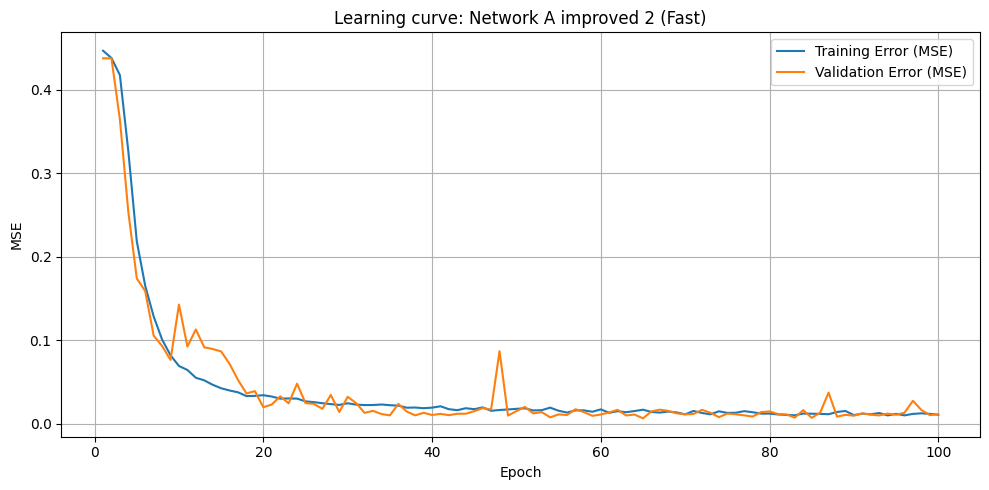

Saved → export/networkA_improv2_fast/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2_fast/trained_weights.csv


In [19]:
NetworkA['eta'] = 0.05 #keep
NetworkA['alpha'] = 0.9 #increasing momentum back
NetworkA['size'] = 12 #keeping size


epochA_improv2_fast = Epoch(split, NetworkA)

train(epochA_improv2_fast, "Learning curve: Network A improved 2 (Fast)")
epochA_improv2_fast.exportAll("export/networkA_improv2_fast/")

As expected, having an aggressive momentum increase does put us back to early epoch convergence, specifically at **40 epochs**, but with a trade-off of a more erratic validation set (less generalized). It is worth noting that training time here is still the same at 60s for 100 epochs, but still having an advantage of being able to stop earlier could mean lowering the training time in half.

### Lowering hidden layer size

Lastly, we are exploring the effects of lowering the hidden layer size. Let's keep the current settings for fast conversion.

Epoch    5  Train: 0.36916  Val: 0.32680  Time: 0.542s
Epoch   10  Train: 0.13762  Val: 0.12536  Time: 0.541s
Epoch   15  Train: 0.10513  Val: 0.09458  Time: 0.638s
Epoch   20  Train: 0.08393  Val: 0.06547  Time: 0.637s
Epoch   25  Train: 0.06723  Val: 0.05404  Time: 0.583s
Epoch   30  Train: 0.06095  Val: 0.05078  Time: 0.540s
Epoch   35  Train: 0.05124  Val: 0.05801  Time: 0.536s
Epoch   40  Train: 0.04461  Val: 0.07458  Time: 0.558s
Epoch   45  Train: 0.04772  Val: 0.03786  Time: 0.531s
Epoch   50  Train: 0.03931  Val: 0.04472  Time: 0.536s
Epoch   55  Train: 0.04135  Val: 0.04214  Time: 0.584s
Epoch   60  Train: 0.03391  Val: 0.04135  Time: 0.586s
Epoch   65  Train: 0.03178  Val: 0.03372  Time: 0.652s
Epoch   70  Train: 0.03026  Val: 0.03021  Time: 0.577s
Epoch   75  Train: 0.03147  Val: 0.03250  Time: 0.571s
Epoch   80  Train: 0.03412  Val: 0.03357  Time: 0.559s
Epoch   85  Train: 0.02755  Val: 0.03100  Time: 0.519s
Epoch   90  Train: 0.02701  Val: 0.03484  Time: 0.560s
Epoch   95

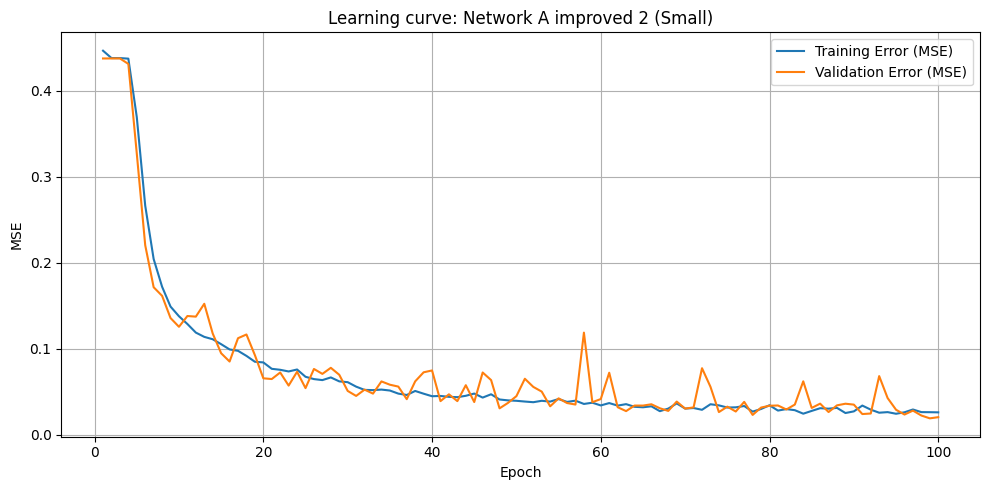

Saved → export/networkA_improv2_small/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2_small/trained_weights.csv


In [20]:
NetworkA['eta'] = 0.05 #keeping learning rate further
NetworkA['alpha'] = 0.9 #increasing momentum back
NetworkA['size'] = 5 #lowering size 


epochA_improv2_small = Epoch(split, NetworkA)

train(epochA_improv2_small, "Learning curve: Network A improved 2 (Small)")
epochA_improv2_small.exportAll("export/networkA_improv2_small/")

Inspiringly, since a good learning rate and momentum has been set, having smaller hidden layer sizes did affect the curve to converge slower with a more erratic validation set. However, it struggles in maintaining an error floor of 0.02000 below for both training and validation. This could be a characteristic of just having very low weight size of the perceptron to allow absolute minimization of errors.

It was noted that a small model would result to a quick Training time of about 58s. This could still be hardware-bound as it does not scale well compared to having 12 weights.

## Training: Network B

Now let us train using Network B uses the **Leaky ReLU** function for hidden layers and the **Logistic** function for the output layer. Testing with the default parameters first to establish a baseline.

Epoch    5  Train: 0.44045  Val: 0.43843  Time: 0.624s
Epoch   10  Train: 0.44045  Val: 0.43843  Time: 0.639s
Epoch   15  Train: 0.44045  Val: 0.43843  Time: 0.696s
Epoch   20  Train: 0.44045  Val: 0.43843  Time: 0.677s
Epoch   25  Train: 0.44045  Val: 0.43843  Time: 0.632s
Epoch   30  Train: 0.44045  Val: 0.43843  Time: 0.732s
Epoch   35  Train: 0.40389  Val: 0.41435  Time: 0.595s
Epoch   40  Train: 0.40993  Val: 0.40543  Time: 0.670s
Epoch   45  Train: 0.39413  Val: 0.38938  Time: 0.706s


C:\Users\C5396183\AppData\Local\Temp\ipykernel_37800\621747645.py:3: RuntimeWarning: overflow encountered in exp
  phi = 1.0 / (1.0 + np.exp(-a * v))


Epoch   50  Train: 0.37194  Val: 0.39025  Time: 0.659s
Epoch   55  Train: 0.45577  Val: 0.45371  Time: 0.660s
Epoch   60  Train: 0.34978  Val: 0.35858  Time: 0.671s
Epoch   65  Train: 0.34054  Val: 0.39307  Time: 0.630s
Epoch   70  Train: 0.47063  Val: 0.46750  Time: 0.708s
Epoch   75  Train: 0.50000  Val: 0.50000  Time: 0.653s
Epoch   80  Train: 0.50000  Val: 0.50000  Time: 0.661s
Epoch   85  Train: 0.50000  Val: 0.50000  Time: 0.739s
Epoch   90  Train: 0.50000  Val: 0.50000  Time: 0.650s
Epoch   95  Train: 0.50000  Val: 0.50000  Time: 0.647s
Epoch  100  Train: 0.50000  Val: 0.50000  Time: 0.692s
Confusion Matrix (rows=Actual, cols=Predicted):
      P 1  P 2  P 3  P 4  P 5  P 6  P 7  P 8
A 1 |    0    89     0     0     0     0     0     0
A 2 |    0    82     0     0     0     0     0     0
A 3 |    0   106     0     0     0     0     0     0
A 4 |    0   119     0     0     0     0     0     0
A 5 |    0    94     0     0     0     0     0     0
A 6 |    0   106     0     0     0   

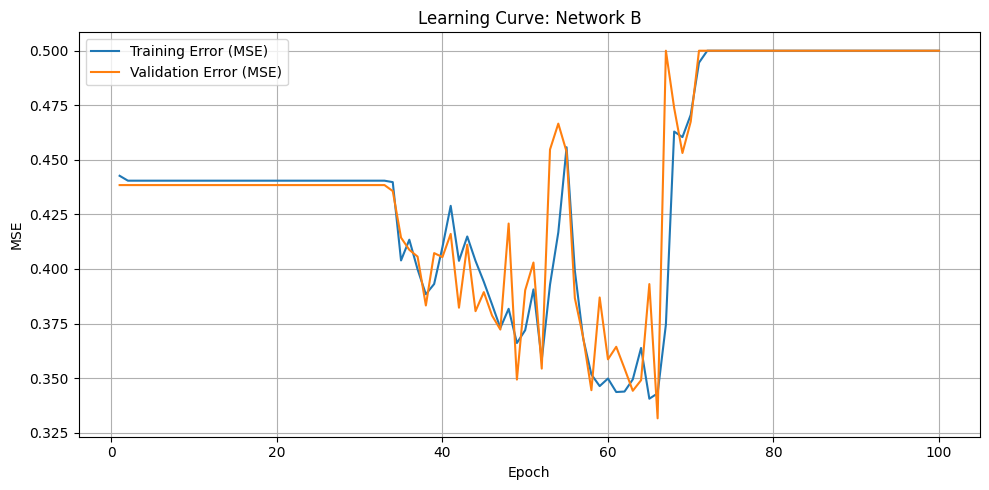

Saved → export/networkB/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB/trained_weights.csv


In [21]:
train(epochB, "Learning Curve: Network B") #network B
epochB.exportAll("export/networkB/")

### Improvements: Network B

The default learning rate of 0.85 is too high — the errors do not change at all, just as observed with Network A. The same tuning strategy is applied: `eta=0.1`, `alpha=0.5`, `size=12`.

Epoch    5  Train: 0.43769  Val: 0.43754  Time: 0.663s
Epoch   10  Train: 0.43765  Val: 0.43751  Time: 0.619s
Epoch   15  Train: 0.34940  Val: 0.33983  Time: 0.658s
Epoch   20  Train: 0.17543  Val: 0.16026  Time: 0.682s
Epoch   25  Train: 0.09687  Val: 0.12948  Time: 0.654s
Epoch   30  Train: 0.06092  Val: 0.05636  Time: 0.654s
Epoch   35  Train: 0.04666  Val: 0.05049  Time: 0.668s
Epoch   40  Train: 0.03841  Val: 0.04988  Time: 0.702s
Epoch   45  Train: 0.03279  Val: 0.03875  Time: 0.708s
Epoch   50  Train: 0.02928  Val: 0.04873  Time: 0.669s
Epoch   55  Train: 0.02531  Val: 0.07903  Time: 0.711s
Epoch   60  Train: 0.02282  Val: 0.03893  Time: 0.801s
Epoch   65  Train: 0.02121  Val: 0.05930  Time: 0.610s
Epoch   70  Train: 0.01951  Val: 0.06302  Time: 0.610s
Epoch   75  Train: 0.01697  Val: 0.03271  Time: 0.653s
Epoch   80  Train: 0.01633  Val: 0.03712  Time: 0.650s
Epoch   85  Train: 0.01521  Val: 0.03617  Time: 0.592s
Epoch   90  Train: 0.01388  Val: 0.02652  Time: 0.703s
Epoch   95

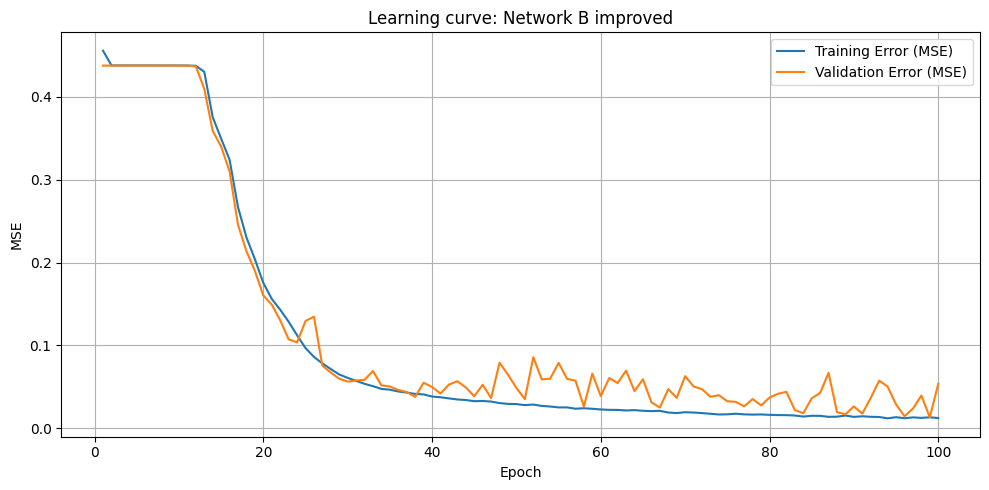

Saved → export/networkB_improv/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv/trained_weights.csv


In [22]:
NetworkB['eta'] = 0.1 #decreasing the learning rate like Network A improv
NetworkB['alpha'] = 0.5 #decreasing the momentum
NetworkB['size'] = 12 #increasing hidden layer nodes

epochB_improv = Epoch(split, NetworkB)

train(epochB_improv, "Learning curve: Network B improved")
epochB_improv.exportAll("export/networkB_improv/")

Though improved, it was noted that the validation errors do not align well with the test errors by the end of the run, specifically due to the large amount of False Positives for Class 6. It is not known yet what causes this, but let's see if things improve when lowering the learning rate. No changes in Training time has been observed, still about 60s.

### Lowering learning rate further

Epoch    5  Train: 0.43762  Val: 0.43758  Time: 0.820s
Epoch   10  Train: 0.43758  Val: 0.43754  Time: 0.617s
Epoch   15  Train: 0.43510  Val: 0.43236  Time: 0.685s
Epoch   20  Train: 0.34960  Val: 0.35062  Time: 0.614s
Epoch   25  Train: 0.25785  Val: 0.23598  Time: 0.613s
Epoch   30  Train: 0.16003  Val: 0.15888  Time: 0.703s
Epoch   35  Train: 0.11702  Val: 0.11555  Time: 0.659s
Epoch   40  Train: 0.06878  Val: 0.06893  Time: 0.699s
Epoch   45  Train: 0.05406  Val: 0.06056  Time: 0.727s
Epoch   50  Train: 0.04585  Val: 0.05240  Time: 0.635s
Epoch   55  Train: 0.03978  Val: 0.03940  Time: 0.625s
Epoch   60  Train: 0.03477  Val: 0.04051  Time: 0.660s
Epoch   65  Train: 0.03046  Val: 0.05465  Time: 0.598s
Epoch   70  Train: 0.02796  Val: 0.04263  Time: 0.643s
Epoch   75  Train: 0.02590  Val: 0.03607  Time: 0.644s
Epoch   80  Train: 0.02293  Val: 0.03345  Time: 0.633s
Epoch   85  Train: 0.02185  Val: 0.02860  Time: 0.636s
Epoch   90  Train: 0.02027  Val: 0.02783  Time: 0.642s
Epoch   95

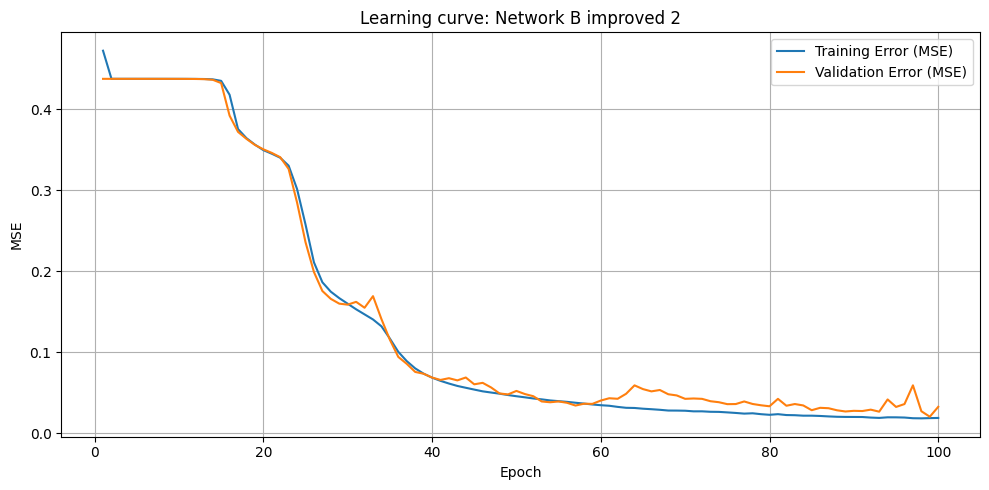

Saved → export/networkB_improv2/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2/trained_weights.csv


In [23]:
NetworkB['eta'] = 0.05 #decreasing the learning rate like Network A improv2
NetworkB['alpha'] = 0.5 #keaping the momentum
NetworkB['size'] = 12 #keep

epochB_improv2 = Epoch(split, NetworkB)

train(epochB_improv2, "Learning curve: Network B improved 2")
epochB_improv2.exportAll("export/networkB_improv2/")

Decreasing learning rate further improved the F1 score and the behavior of the validation set at the end of the 100 epoch run, though it still struggled to keep a low error in the middle with Class 6 still the culprit. Weights showed improvement at around the 20th epoch, but this is expected with the very low learning rate.

Looking back to the distribution of SMOTE, there is no evidence of an unbalanced dataset causing the issue as the classe 6 which got misclassified are big enough datasets at the start, with SMOTE distributing them more evenly.

### Increasing momentum

To attempt to reduce the false positives, lets see if momentum increase will improve the classifications.

Epoch    5  Train: 0.43773  Val: 0.43744  Time: 0.679s
Epoch   10  Train: 0.25581  Val: 0.23255  Time: 0.616s
Epoch   15  Train: 0.11824  Val: 0.10895  Time: 0.790s
Epoch   20  Train: 0.08287  Val: 0.07417  Time: 0.687s
Epoch   25  Train: 0.05743  Val: 0.14092  Time: 0.687s
Epoch   30  Train: 0.05312  Val: 0.04923  Time: 0.605s
Epoch   35  Train: 0.04688  Val: 0.02816  Time: 0.690s
Epoch   40  Train: 0.04089  Val: 0.09658  Time: 0.740s
Epoch   45  Train: 0.03661  Val: 0.03059  Time: 0.734s
Epoch   50  Train: 0.03561  Val: 0.04090  Time: 0.645s
Epoch   55  Train: 0.04280  Val: 0.04228  Time: 0.656s
Epoch   60  Train: 0.02995  Val: 0.02431  Time: 0.755s
Epoch   65  Train: 0.03183  Val: 0.04329  Time: 0.688s
Epoch   70  Train: 0.02840  Val: 0.05074  Time: 0.765s
Epoch   75  Train: 0.02551  Val: 0.03267  Time: 0.702s
Epoch   80  Train: 0.02488  Val: 0.03043  Time: 0.701s
Epoch   85  Train: 0.02595  Val: 0.02647  Time: 0.643s
Epoch   90  Train: 0.02614  Val: 0.02873  Time: 0.674s
Epoch   95

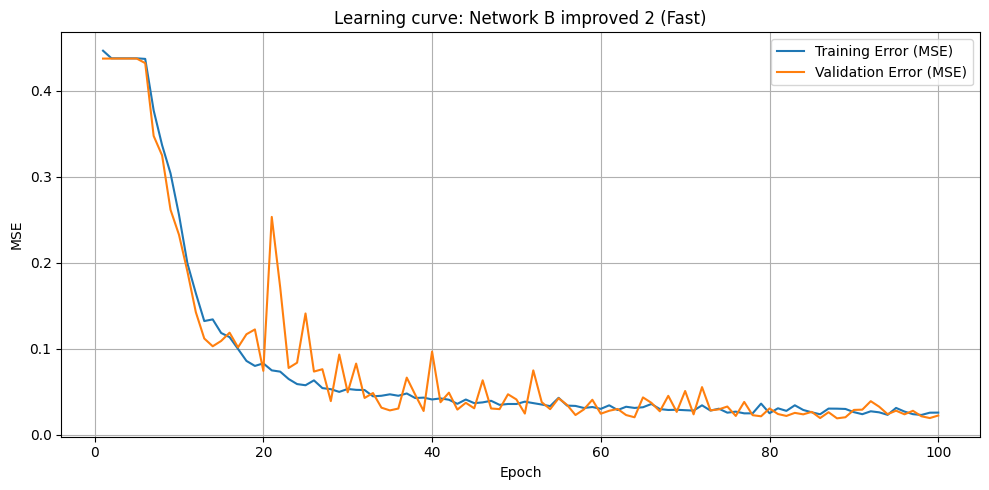

Saved → export/networkB_improv2_fast/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2_fast/trained_weights.csv


In [24]:
NetworkB['eta'] = 0.05 #decreasing the learning rate like Network A improv2
NetworkB['alpha'] = 0.9 #keaping the momentum
NetworkB['size'] = 12 #increasing hidden layer nodes

epochB_improv2_fast = Epoch(split, NetworkB)

train(epochB_improv2_fast, "Learning curve: Network B improved 2 (Fast)")
epochB_improv2_fast.exportAll("export/networkB_improv2_fast/")

Now this is a big improvement in lowering the False Positives from 19 to 3 for Class 6. Errors have converged erratically with a high floor, not reaching the target 02000.

### Lowering hidden layer size

Let's see if we can keep the improvements while lowering the hidden layer size.

Epoch    5  Train: 0.43773  Val: 0.43728  Time: 0.619s
Epoch   10  Train: 0.22894  Val: 0.20787  Time: 0.612s
Epoch   15  Train: 0.14510  Val: 0.14853  Time: 0.636s
Epoch   20  Train: 0.11417  Val: 0.09671  Time: 0.680s
Epoch   25  Train: 0.09564  Val: 0.10376  Time: 0.599s
Epoch   30  Train: 0.18600  Val: 0.13561  Time: 0.620s
Epoch   35  Train: 0.06895  Val: 0.06443  Time: 0.601s
Epoch   40  Train: 0.06582  Val: 0.03708  Time: 0.608s
Epoch   45  Train: 0.06856  Val: 0.07435  Time: 0.583s
Epoch   50  Train: 0.06551  Val: 0.08853  Time: 0.610s


C:\Users\C5396183\AppData\Local\Temp\ipykernel_37800\621747645.py:3: RuntimeWarning: overflow encountered in exp
  phi = 1.0 / (1.0 + np.exp(-a * v))


Epoch   55  Train: 0.06088  Val: 0.03611  Time: 0.579s
Epoch   60  Train: 0.06291  Val: 0.08798  Time: 0.629s
Epoch   65  Train: 0.05648  Val: 0.05325  Time: 0.639s
Epoch   70  Train: 0.06477  Val: 0.03758  Time: 0.621s
Epoch   75  Train: 0.08304  Val: 0.04730  Time: 0.726s
Epoch   80  Train: 0.06588  Val: 0.04727  Time: 0.687s
Epoch   85  Train: 0.08257  Val: 0.20137  Time: 0.648s
Epoch   90  Train: 0.05217  Val: 0.02863  Time: 0.693s
Epoch   95  Train: 0.08317  Val: 0.07678  Time: 0.650s
Epoch  100  Train: 0.06634  Val: 0.07693  Time: 0.676s
Confusion Matrix (rows=Actual, cols=Predicted):
      P 1  P 2  P 3  P 4  P 5  P 6  P 7  P 8
A 1 |   79     2     0     0     0     0     0     8
A 2 |    0    73     1     0     0     5     0     3
A 3 |    0     0   106     0     0     0     0     0
A 4 |    0     0     0   111     0     3     0     5
A 5 |    0     0     0     0    94     0     0     0
A 6 |    1     0     0     0     0    93     0    12
A 7 |    0     0     0     0     0     

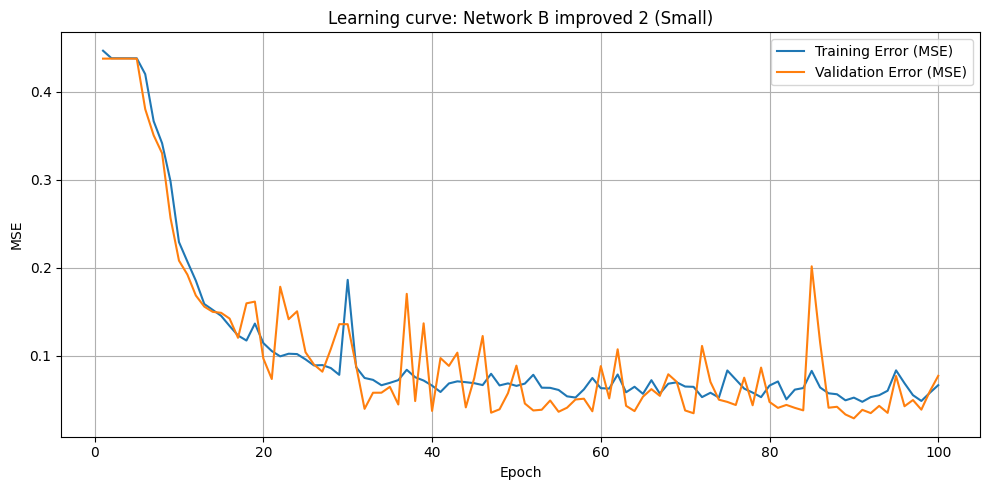

Saved → export/networkB_improv2_small/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2_small/trained_weights.csv


In [25]:
NetworkB['eta'] = 0.05 #keeping the learning rate like Network A improv2 fast
NetworkB['alpha'] = 0.9 #increasing the momentum
NetworkB['size'] = 5 #decreasing hidden nodes

epochB_improv2_small = Epoch(split, NetworkB)

train(epochB_improv2_small, "Learning curve: Network B improved 2 (Small)")
epochB_improv2_small.exportAll("export/networkB_improv2_small/")

This time, no improvements were recorded when changing the hidden layer size down to 5.

# Training Results

After training all network configurations, the results are compiled and ranked by F1 score and approximate epoch of convergence. Time was recorded when convergence was met.

In [31]:
!python checkscores.py

Loaded 1 rows from networkA
Loaded 1 rows from networkA_improv
Loaded 1 rows from networkA_improv2
Loaded 1 rows from networkA_improv2_fast
Loaded 1 rows from networkA_improv2_small
Loaded 1 rows from networkB
Loaded 1 rows from networkB_improv
Loaded 1 rows from networkB_improv2
Loaded 1 rows from networkB_improv2_fast
Loaded 1 rows from networkB_improv2_small

Combined 10 total rows written to combined_scores.csv
Full scores written to final\full_scores.csv
Best score written to final\scores.csv (Network: networkA_improv2_fast, F1: 0.985182)


## Results
| Rank | network                | Epoch converged at | f1          | time          |
|------|-------------------------|---------------------|-------------|----------------|
| 1    | networkA_improv2_fast  | 40                 | 0.985182453 | 60.46645784    |
| 2    | networkA_improv        | 50                  | 0.981435508 | 66.86948276    |
| 3    | networkA_improv2       | 100                 | 0.981307373 | 64.91645789    |
| 4    | networkA_improv2_small | 100                 | 0.977521438 | 58.80456924    |
| 5    | networkB_improv2_fast  | 100+                | 0.978736687 | 68.39886546    |
| 6    | networkB_improv2       | 100+                | 0.96407974  | 67.12348247    |
| 7    | networkB_improv        | 100+                | 0.934110529 | 66.30333638    |
| 8    | networkB_improv2_small | 100+                | 0.918329517 | 63.74193907    |
| 9    | networkA               | NA                  | 0.029249448 | 59.16867375    |
| 10   | networkB               | NA                  | 0.02324263  | 67.36797047    |

## Full Scores Results

| Rank | network                | Epoch converged at | accuracy  | precision    | recall   | f1          | matthews   | time          |
|------|-------------------------|---------------------|-----------|--------------|----------|-------------|------------|----------------|
| 1    | networkA_improv2_fast  | 40                 | 0.985     | 0.985789431  | 0.984964 | 0.985182453 | 0.98288786 | 60.46645784    |
| 2    | networkA_improv        | 50                  | 0.98125   | 0.981845312  | 0.981469 | 0.981435508 | 0.97860017 | 66.86948276    |
| 3    | networkA_improv2       | 100                 | 0.98125   | 0.98220687   | 0.981481 | 0.981307373 | 0.97870081 | 64.91645789    |
| 4    | networkA_improv2_small | 100                 | 0.9775    | 0.977727235  | 0.977609 | 0.977521438 | 0.97429422 | 58.80456924    |
| 5    | networkB_improv2_fast  | 100+                | 0.97875   | 0.978548905  | 0.979146 | 0.978736687 | 0.97570944 | 68.39886546    |
| 6    | networkB_improv2       | 100+                | 0.96375   | 0.966801473  | 0.964059 | 0.96407974  | 0.95892809 | 67.12348247    |
| 7    | networkB_improv        | 100+                | 0.93375   | 0.949366475  | 0.935517 | 0.934110529 | 0.92686404 | 66.30333638    |
| 8    | networkB_improv2_small | 100+                | 0.915     | 0.932221889  | 0.914188 | 0.918329517 | 0.90458739 | 63.74193907    |
| 9    | networkA               | NA                  | 0.1325    | 0.0165625    | 0.125    | 0.029249448 | 0.0        | 59.16867375    |
| 10   | networkB               | NA                  | 0.1025    | 0.0128125    | 0.125    | 0.02324263  | 0.0        | 67.36797047    |

**Network A (improved2, Fast)** with Tanh is the best training setup for Network A with **0.98518 F1 score** and converges to 0.02 MSE on the 40th Epoch. Since stopping early is an option, training time (adjusted) should be about **24 seconds**. Its trained weights are exported to `modelA/trained_weights.csv` as the primary model for the unseen test set.

**Network B (improved2, fast)** with Leaky RELU is the best training setup for Network B with a close **0.97873 F1 score**. It does not converge fast enough to cut off training time. Its weights are exported to `modelB/trained_weights.csv` as the backup model.

The bottom three configurations (all using default hyperparameters) achieved near-zero F1 scores with MCC of 0.0, confirming they learned nothing meaningful.

In [45]:
epochA_improv2_fast.exportWeights("modelA/")
epochB_improv2_fast.exportWeights("modelB/")

Saved → modelA/trained_weights.csv
Saved → modelB/trained_weights.csv


## Loading the Model

Trained weights are loaded from CSV files using the `loadWeights` function. The function reads the weight matrix, parses the layer dimensions, and returns properly shaped arrays ready for reconstruction.

In [46]:
def loadWeights(path):
    blocks = {'Wi': [], 'Wj': [], 'Wk': []}
    current = None
    with open(path, newline='') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row or row[0].strip() == '':
                continue
            tag = row[0].strip()
            if tag in blocks:
                current = tag
                continue
            if current is not None:
                blocks[current].append([float(v) for v in row])
    return (np.array(blocks['Wi']),
            np.array(blocks['Wj']),
            np.array(blocks['Wk']))

## Running and Exporting the Predictions

The `runPredictions` function takes the loaded weights and test set, reconstructs the network layers, and performs a forward pass for each test sample. Predictions are determined by taking the `argmax` of the output layer activations.

The best two models are used:
- **Network B improved** (Leaky ReLU) → `predictions/networkB_improv_predictions.csv`
- **Network A improved fast** (Tanh) → `predictions/networkA_improv_fast_predictions.csv`

In [47]:
def runPredictions(model, testset, cfg):
    if isinstance(model, tuple):
        Wi, Wj, Wk = model
        layerI = HiddenLayer(cfg['methods'][0], Wi, cfg, size=Wi.shape[0])
        layerJ = HiddenLayer(cfg['methods'][1], Wj, cfg, size=Wj.shape[0])
        layerK = OutputLayer(cfg['methods'][2], Wk, cfg)
    else:
        layerI = model.hiddenlayer_i
        layerJ = model.hiddenlayer_j
        layerK = model.outputlayer_k

    predictions = []
    for x in testset:
        xb   = np.concatenate(([1.0], np.asarray(x, dtype=float)))
        phiI = layerI.forward(xb)
        phiJ = layerJ.forward(phiI)
        layerK.forward(phiJ)
        label = int(np.argmax(layerK.o)) + 1
        predictions.append(label)
    return predictions

def exportPredictions(predictions, filename="predictions_for_test_networkA.csv"):
    outputdir = "predictions"
    os.makedirs(outputdir, exist_ok=True)
    filepath = os.path.join(outputdir, filename)
    with open(filepath, 'w', newline='') as f:
        writer = csv.writer(f)
        for p in predictions:
            writer.writerow([p])
    print(f"Saved {len(predictions)} predictions → {filepath}")

In [48]:
#for sanity's sake, this is the parsed  TESTSET from test_set.csv
print(TESTSET)
print(f"TESTSET : {TESTSET.shape}")

[[2.2071e-02 1.5208e-02 0.0000e+00 ... 4.9787e-03 9.8536e-01 6.6436e-02]
 [2.7050e-02 1.4022e-02 8.7247e-04 ... 2.5246e-02 9.0283e-01 2.7611e-01]
 [4.0489e-02 2.9229e-02 1.7990e-03 ... 1.0859e-02 9.2096e-01 2.6831e-01]
 ...
 [1.6607e-02 2.0379e-02 5.2598e-04 ... 4.4773e-03 9.8416e-01 8.9833e-02]
 [5.6162e-03 5.2749e-03 0.0000e+00 ... 7.8382e-03 9.7868e-01 1.4204e-01]
 [1.1618e-02 1.1367e-02 1.9311e-04 ... 9.4570e-03 8.8809e-01 2.1509e-01]]
TESTSET : (701, 354)


In [49]:
WEIGHTSA = os.path.join("modelA", "trained_weights.csv") #tanh
WEIGHTSB = os.path.join("modelB", "trained_weights.csv") #leakyrelu

MODELA = loadWeights(WEIGHTSA)
MODELB = loadWeights(WEIGHTSB)

predictions_tanh = runPredictions(MODELA, TESTSET, NetworkA)
predictions_relu = runPredictions(MODELB, TESTSET, NetworkB)

#exporting predictions
exportPredictions(predictions_tanh, filename="predictions_for_test_tanh.csv")
exportPredictions(predictions_relu, filename="predictions_for_test_leakyrelu.csv")


Saved 701 predictions → predictions\predictions_for_test_tanh.csv
Saved 701 predictions → predictions\predictions_for_test_leakyrelu.csv


# Conclusion and Recommendations



**Key takeaways:**

1. **Learning rate dominates early performance.** 

2. **Leaky ReLU outperformed Tanh.** 

3. **Hidden layer size has diminishing returns.** 

4. **Early stopping is recommended.** 

5. **SMOTE effectively addressed class imbalance,** 

6. **Momentum should complement, not dominate.** 